# Visualization and validation of training datasets

This script produces the plots used in the report (ref) for Visualization and validation of the datasets used for GAN training, validation and testing.

## Add Packages

In [28]:
import os
import re
import sys
from pathlib import Path
import glob
import numpy as np
from tqdm import tqdm
import json
import random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

# Set seed
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)

### Set paths and add custom functions

In [29]:
file_dir = os.getcwd()
output_dir = os.path.join(file_dir, 'datasets')
base_dir = Path(os.getcwd()).parent

print(f"Base directory: {base_dir}")
print(f"Current file located in: {os.getcwd()}")
print(f"Output directory: {output_dir}")

# Import custom libs
if str(base_dir) not in sys.path:
    sys.path.insert(0, str(base_dir))

import scripts.gan_pipeline.core.custom_plots as custom_plots


custom_plots.apply_custom_plotting_flavor()
facies_properties = json.load(open(os.path.join(base_dir, 'scripts\\gan_pipeline\\core\\facies_config.json'), 'r'))

val_to_color = {data['val']: data['color'] for facies, data in facies_properties.items()}

Base directory: c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM
Current file located in: c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots
Output directory: c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\datasets


## Load data

In [36]:
data_dir = os.path.join(base_dir, 'datasets','training','setting_1_nexus_1000_samples_ntg_0.67_chdepth_6_isbx_100','samples','facies','*.npy')
samples = sorted(glob.glob(data_dir))
num_samples = len(samples)

# Load one sample
exsample = np.load(samples[0])
unique_facies = np.unique(exsample)

print(f"Found {num_samples} total samples in directory: {data_dir}.")
print(f"Shape of sample 1: {np.shape(exsample)}")
print(f"In sample 1 we can find {len(unique_facies)} unique values: {unique_facies}")

Found 1000 total samples in directory: c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\datasets\training\setting_1_nexus_1000_samples_ntg_0.67_chdepth_6_isbx_100\samples\facies\*.npy.
Shape of sample 1: (32, 128, 128)
In sample 1 we can find 9 unique values: [1 2 3 4 5 6 7 8 9]


In [4]:
num_classes = 10
global_counts = np.zeros(num_classes, dtype=np.int64)
total_voxels = 0


for i, sample_path in tqdm(enumerate(samples), desc="Processing Training Data"):
    data = np.load(sample_path)
    unique_facies = np.unique(data)

    # np.bincount is the fastest way to count integers in NumPy
    counts = np.bincount(data.flatten().astype(int), minlength=num_classes)
    global_counts += counts
    total_voxels += data.size

# Convert counts to percentages
percentages = (global_counts / total_voxels) * 100

Processing Training Data: 1000it [01:00, 16.59it/s]


## 2D visualization & Distribution

ValueError: Invalid RGBA argument: 0

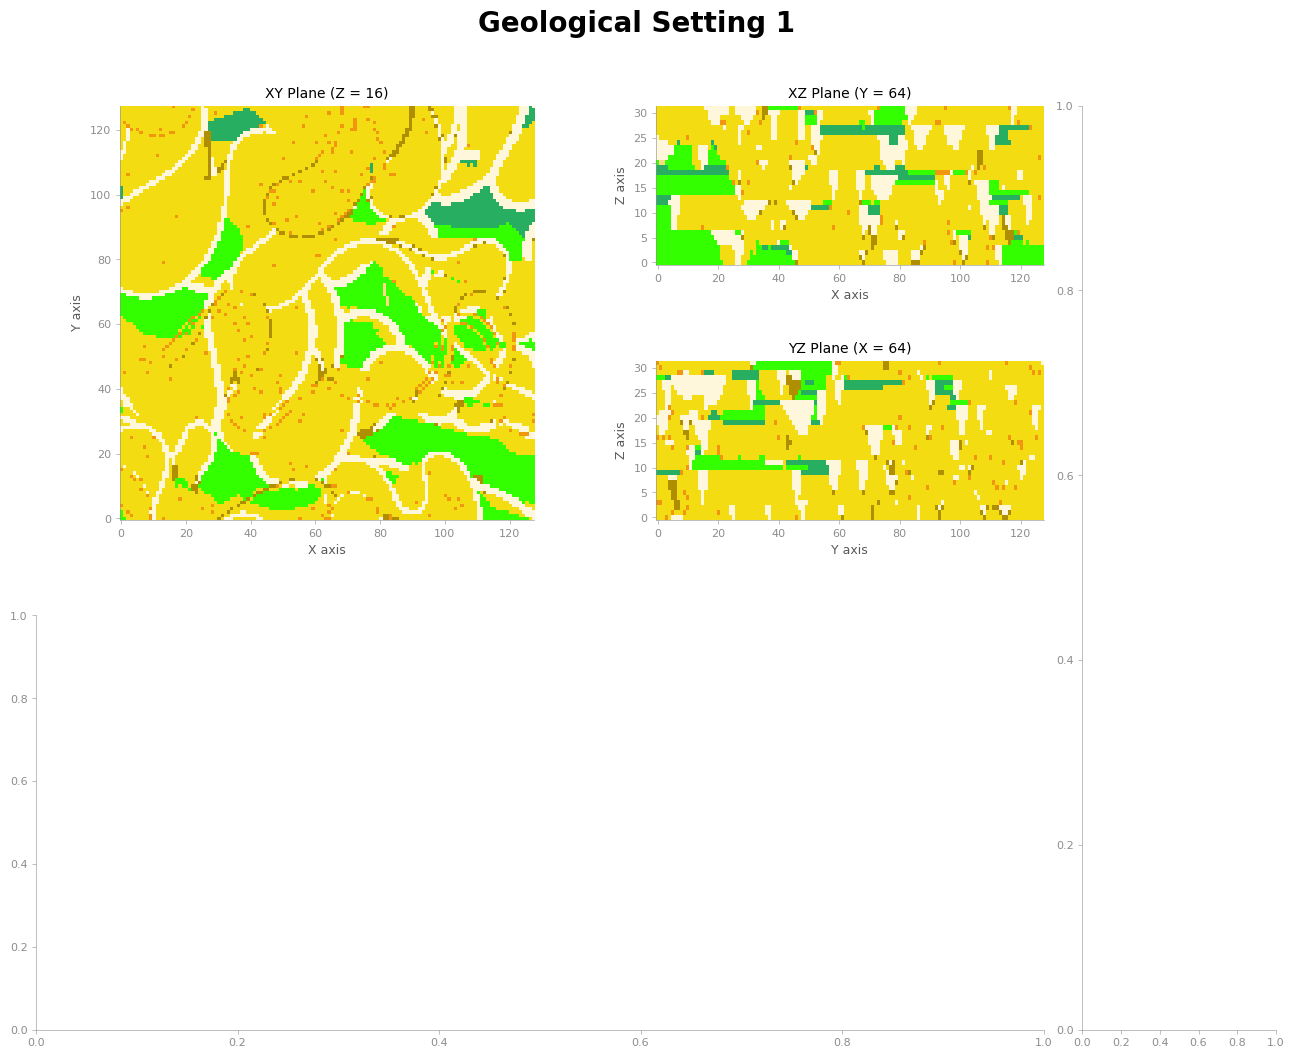

In [7]:
visual_sample_path = random.choice(samples)
filename = os.path.basename(visual_sample_path)
match = re.search(r'\d+', filename)
sample_number = match.group() if match else "Unknown"
visual_data = np.load(visual_sample_path) 
nz, ny, nx = visual_data.shape

slice_z = nz // 2
slice_y = ny // 2
slice_x = nx // 2

xy_slice = visual_data[slice_z, :, :]
xz_slice = visual_data[:, slice_y, :]
yz_slice = visual_data[:, :, slice_x]

# 2. Utilize your custom colormap and norm directly from custom_plots.py
cmap = custom_plots.FaciesColorMap()
norm = custom_plots.FaciesColorMap.get_norm()

# Setup Figure - Increased height slightly to accommodate two full rows
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Geological Setting 1", fontsize=20, y=0.96, fontweight='bold')

# Create a 2x4 grid
# width_ratios: XY gets a bit more space, XZ/YZ equal, Legend gets the remainder
gs = gridspec.GridSpec(4, 3, width_ratios=[1.5, 1.0, 0.5], hspace=0.6, wspace=0.1)

# --- Subplot Allocations ---
ax_xy  = fig.add_subplot(gs[0:2, 0])      # Top row, Col 0
ax_xz  = fig.add_subplot(gs[0, 1])      # Top row, Col 1
ax_yz  = fig.add_subplot(gs[1, 1])      # Top row, Col 2
ax_fac = fig.add_subplot(gs[2:4, 0:2])    # Bottom row, Spans Cols 0, 1, and 2
ax_leg = fig.add_subplot(gs[:, 2])      # Spans both rows in Col 3

# --- Row 1: Facies 2D Slices ---
ax_xy.imshow(xy_slice, cmap=cmap, norm=norm, origin='lower', aspect='equal')
ax_xy.set_title(f'XY Plane (Z = {slice_z})')
ax_xy.set_xlabel('X axis')
ax_xy.set_ylabel('Y axis')

ax_xz.imshow(xz_slice, cmap=cmap, norm=norm, origin='lower', aspect='auto')
ax_xz.set_title(f'XZ Plane (Y = {slice_y})')
ax_xz.set_xlabel('X axis')
ax_xz.set_ylabel('Z axis')

ax_yz.imshow(yz_slice, cmap=cmap, norm=norm, origin='lower', aspect='auto')
ax_yz.set_title(f'YZ Plane (X = {slice_x})')
ax_yz.set_xlabel('Y axis')
ax_yz.set_ylabel('Z axis')

# --- Row 2: Facies Distribution Bar Chart ---
bars = ax_fac.bar(
    x=range(num_classes), 
    height=percentages, 
    width=1.0, 
    color=val_to_color,
    edgecolor='white', 
    linewidth=0.5
)

ax_fac.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)
ax_fac.set_title(f"Facies Distribution {num_samples} samples", fontweight='normal', pad = 10)
ax_fac.set_ylabel("Percentage (%)")
ax_fac.set_xlabel("Facies Class")
ax_fac.set_xticks(range(num_classes))
ax_fac.set_ylim(0, max(percentages) * 1.15) # Give top labels room to breathe

# --- Last Column: Shared Legend ---
ax_leg.axis('off') 

# Note: Using `unique_facies` (the global one) rather than `unique_facies_in_sample`
# This ensures that all colors present in your Bar Chart have a corresponding legend entry!
legend_elements = []
for f_name, f_props in facies_properties.items():
    if f_props['val'] in unique_facies:
        patch = mpatches.Patch(
            color=f_props['color'], 
            label=f"{f_props['val']} - {f_name.replace('_', ' ').title()}"
        )
        legend_elements.append(patch)

ax_leg.legend(
    handles=legend_elements, 
    loc='center left', 
    title="Legend of Facies",
    title_fontsize=12,
    fontsize=10,
    frameon=False, 
    labelspacing=1.2
)

# Save and Show
output_plot_path = "Geological_Setting_1_Summary.png"
plt.savefig(output_plot_path, dpi=400, bbox_inches='tight')
plt.show()

## Create 3D plots

In [26]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

def plot_3d_facies(samples, facies_properties, custom_plots, show_legend=True, max_facies_to_plot=None):
    """
    Generates a single 3D PyVista plot of all facies from a random sample,
    and displays it with a clean Matplotlib categorical legend.
    
    Parameters:
    -----------
    samples : list
        List of file paths to the .npy sample files.
    facies_properties : dict
        Dictionary containing configuration values, colors, and names of facies.
    custom_plots : module/object
        The custom plotting module containing FaciesColorMap.
    show_legend : bool, default True
        If True, renders the Matplotlib categorical legend on the right.
    max_facies_to_plot : int, optional
        If set, restricts the rendering to only include the first 'N' unique 
        facies found in the volume (useful for decluttering complex volumes).
    """
    print("\n--- Phase 4: Generating Configurable 3D Plot ---")

    try:
        import pyvista as pv
    except ImportError:
        print("Error: 'pyvista' is not installed. Cannot run 3D plotting.")
        return None

    # 1. Select a random sample and load data
    if not samples:
        raise FileNotFoundError("No .npy files found in the 'samples' list.")
        
    random_file = random.choice(samples)
    data_3d = np.load(random_file)
    nz, ny, nx = data_3d.shape
    
    # Identify unique facies present in this specific block
    present_facies = np.unique(data_3d).astype(int)
    
    # Dynamic Filtering: Restrict number of facies plotted if requested
    if max_facies_to_plot is not None and max_facies_to_plot < len(present_facies):
        print(f"Limiting display from {len(present_facies)} facies down to {max_facies_to_plot}.")
        present_facies = present_facies[:max_facies_to_plot]
        
        # Mask out data points that aren't in our restricted list (set to background/0 or NaN)
        mask = np.isin(data_3d, present_facies)
        render_data = np.where(mask, data_3d, 0) # Fallback to 0 if excluded
    else:
        render_data = data_3d

    # 2. Setup the PyVista Grid
    grid = pv.ImageData()
    grid.dimensions = (nx + 1, ny + 1, nz + 1)
    grid.cell_data['Facies'] = render_data.transpose(2, 1, 0).flatten(order='F')

    custom_cmap = custom_plots.FaciesColorMap()

    # 3. Render 3D Scene off-screen
    plotter = pv.Plotter(off_screen=True, window_size=(1200, 1200))
    plotter.background_color = 'white'
    
    plotter.add_mesh(
        grid, 
        scalars='Facies',
        cmap=custom_cmap, 
        clim=[0, 13], 
        show_edges=False, 
        show_scalar_bar=False, # Handled via Matplotlib instead
        ambient=0.3,
        diffuse=0.7
    )
    plotter.view_isometric()
    
    # Capture image array directly from memory
    three_d_image = plotter.screenshot(None)
    plotter.close()

    # 4. Create Matplotlib Canvas for Final Layout Strategy
    # Dynamically change layout configuration based on whether legend is enabled
    if show_legend:
        fig = plt.figure(figsize=(14, 10))
        gs = gridspec.GridSpec(1, 2, width_ratios=[1.8, 0.6], wspace=0.05)
        ax_plot = fig.add_subplot(gs[0, 0])
        ax_leg  = fig.add_subplot(gs[0, 1])
        fig.suptitle("Complete 3D Facies Model", fontsize=20, y=0.95, fontweight='bold')
    else:
        fig = plt.figure(figsize=(10, 16))
        ax_plot = fig.add_subplot(1, 1, 1)

    # Display PyVista matrix inside Matplotlib frame
    ax_plot.imshow(three_d_image)
    ax_plot.axis('off')

    # 5. Build Clean Categorical Legend conditionally
    if show_legend:
        ax_leg.axis('off') 
        legend_elements = []
        
        for f_name, f_props in facies_properties.items():
            if f_props['val'] in present_facies:
                patch = mpatches.Patch(
                    color=f_props['color'], 
                    label=f"{f_props['val']} - {f_name.replace('_', ' ').title()}"
                )
                legend_elements.append(patch)

        ax_leg.legend(
            handles=legend_elements, 
            loc='center left', 
            title="Legend of Facies",
            title_fontsize=13,
            fontsize=11,
            frameon=False, 
            labelspacing=1.4
        )

    # 6. Save Combined Plot
    sample_name = os.path.splitext(os.path.basename(random_file))[0]
    output_plot_path = f"3D_plot_{sample_name}_final.png"
    plt.savefig(output_plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Successfully saved plot execution matrix to: {output_plot_path}")
    return output_plot_path


--- Phase 4: Generating Configurable 3D Plot ---


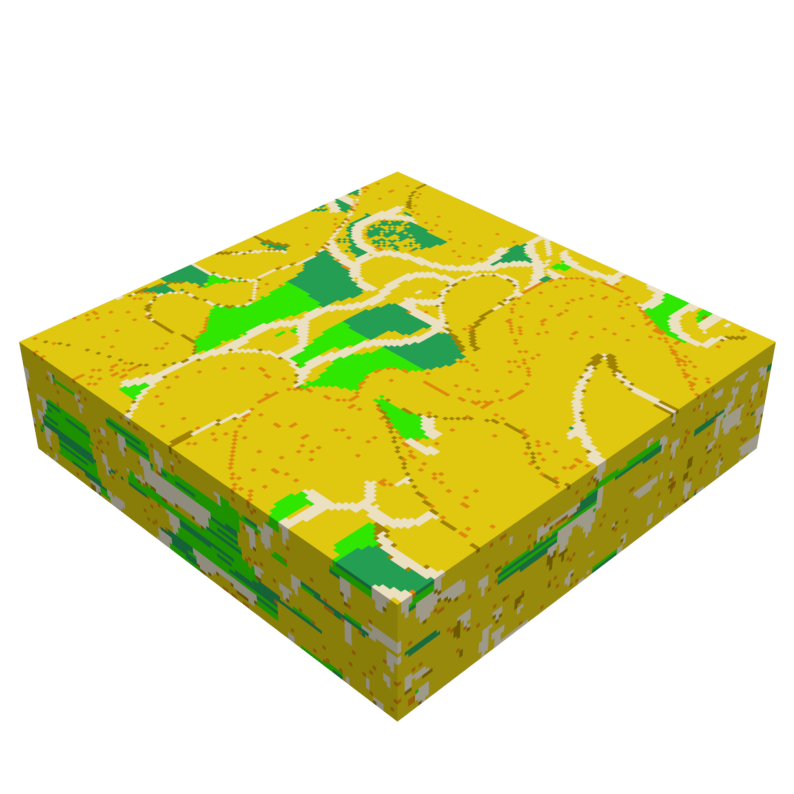

Successfully saved plot execution matrix to: 3D_plot_sample_642_final.png


'3D_plot_sample_642_final.png'

In [27]:
plot_3d_facies(samples, facies_properties, custom_plots, show_legend=False)


--- Phase 4: Generating 3D Plot with Matplotlib Categorical Legend ---


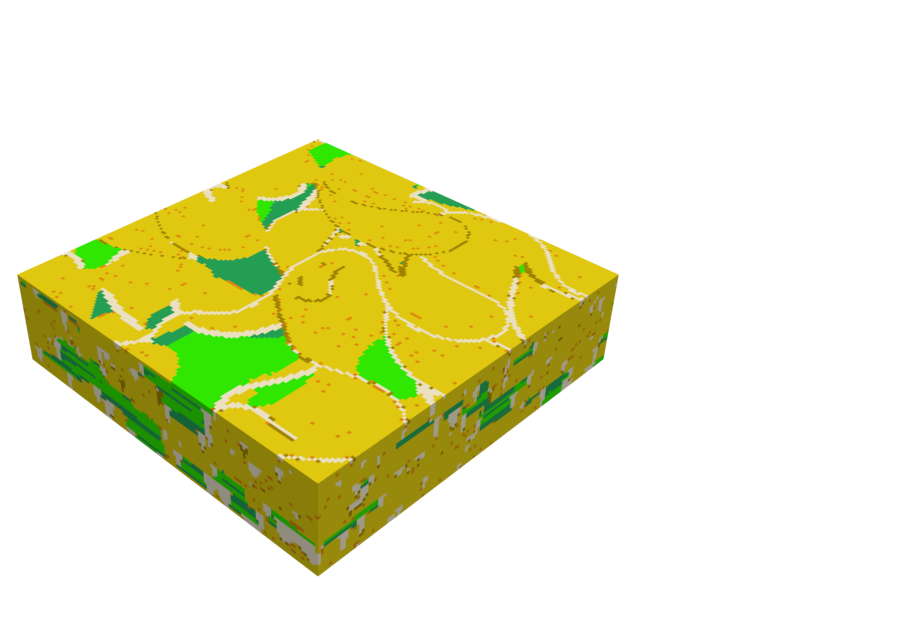

Successfully saved combined 3D plot and clean legend to: 3D_plot_sample_778_with_legend.png


In [13]:
import math
import os
import random
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

print("\n--- Phase 4: Generating 3D Plot with Matplotlib Categorical Legend ---")

try:
    import pyvista as pv
except ImportError:
    print("Error: 'pyvista' is not installed.")
    pv = None

if pv:
    # 1. Select a random sample and load data
    if not samples:
        raise FileNotFoundError("No .npy files found in the 'samples' list.")
        
    random_file = random.choice(samples)
    data_3d = np.load(random_file)
    nz, ny, nx = data_3d.shape
    present_facies = np.unique(data_3d).astype(int)

    # 2. Setup the PyVista Grid
    grid = pv.ImageData()
    grid.dimensions = (nx + 1, ny + 1, nz + 1)
    grid.cell_data['Facies'] = data_3d.transpose(2, 1, 0).flatten(order='F')

    custom_cmap = custom_plots.FaciesColorMap()

    # 3. Render 3D Scene to an image array (No scalar bar here)
    plotter = pv.Plotter(off_screen=True, window_size=(1200, 1200))
    plotter.background_color = 'white'
    
    plotter.add_mesh(
        grid, 
        scalars='Facies',
        cmap=custom_cmap, 
        clim=[0, 13], 
        show_edges=False, 
        show_scalar_bar=False,  # Turned OFF to handle via Matplotlib instead
        ambient=0.3,
        diffuse=0.7
    )
    plotter.view_isometric()
    
    # Capture the image array directly from memory
    three_d_image = plotter.screenshot(None)
    plotter.close()

    # 4. Create Matplotlib Canvas for Layout Strategy
    fig = plt.figure(figsize=(14, 8))
    #fig.suptitle("Complete 3D Facies Model", fontsize=20, y=0.95, fontweight='bold')

    # 1 row, 2 columns: Left for 3D plot, Right for Legend
    gs = gridspec.GridSpec(1, 2, width_ratios=[2, 0.1], wspace=0.05)
    ax_plot = fig.add_subplot(gs[0, 0])
    ax_leg  = fig.add_subplot(gs[0, 1])

    # Display the PyVista image array
    ax_plot.imshow(three_d_image)
    ax_plot.axis('off')  # Hide the pixel bounding box dimensions

    # 5. Build the Clean Categorical Legend
    ax_leg.axis('off') 
    legend_elements = []
    
    for f_name, f_props in facies_properties.items():
        if f_props['val'] in present_facies:
            patch = mpatches.Patch(
                color=f_props['color'], 
                label=f"{f_props['val']} - {f_name.replace('_', ' ').title()}"
            )
            legend_elements.append(patch)

    # ax_leg.legend(
    #     handles=legend_elements, 
    #     loc='center left', 
    #     title="Legend of Facies",
    #     title_fontsize=13,
    #     fontsize=11,
    #     frameon=False, 
    #     labelspacing=1.4
    # )

    # 6. Save Combined Summary Plot
    sample_name = os.path.splitext(os.path.basename(random_file))[0]
    output_plot_path = f"3D_plot_{sample_name}_with_legend.png"
    plt.savefig(output_plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Successfully saved combined 3D plot and clean legend to: {output_plot_path}")

In [ ]:
print("\n--- Phase 4: Generating 3D PyVista Plot ---")

try:
    import pyvista as pv
except ImportError:
    print("Error: 'pyvista' is not installed. Please install it to run this cell.")
    pv = None

if pv:
    # 1. Select a random sample from the previously defined 'samples' list
    if not samples:
        raise FileNotFoundError("No .npy files found in the 'samples' list.")
        
    random_file = random.choice(samples)
    data_3d = np.load(random_file)
    nz, ny, nx = data_3d.shape

    # 2. Setup the PyVista Grid
    grid = pv.ImageData()
    grid.dimensions = (nx + 1, ny + 1, nz + 1)

    # Flatten the data in Fortran order for correct spatial mapping in PyVista
    grid.cell_data['Facies'] = data_3d.transpose(2, 1, 0).flatten(order='F')

    # 3. Define Facies to Plot
    facies_to_plot = [2, 5, 8]
    facies_titles = {2: "Point Bar", 5: "Crevasse Channel", 8: "Overbank"}
    
    # Grab the custom colormap from your configuration
    custom_cmap = custom_plots.FaciesColorMap()

    # 4. Setup Plotter (1 row, 3 columns)
    # Using off_screen=True to render the high-res image smoothly in the background
    plotter = pv.Plotter(shape=(1, 3), off_screen=True, window_size=(2400, 800))

    for i, f_val in enumerate(facies_to_plot):
        plotter.subplot(0, i)
        
        # Add title text for each subplot
        plotter.add_text(f"{f_val} - {facies_titles.get(f_val, f'Facies {f_val}')}", font_size=16, color='black', shadow=False)
        
        # Threshold to only include the current facies
        threshed = grid.threshold([f_val - 0.5, f_val + 0.5], scalars='Facies')

        if threshed.n_points > 0:
            plotter.add_mesh(
                threshed, 
                scalars='Facies',
                cmap=custom_cmap, 
                clim=[0, 13],       # Ensures the colors match your 0-13 facies integer mapping
                show_edges=False, 
                show_scalar_bar=False,
                ambient=0.2,
                diffuse=0.8
            )

        plotter.view_isometric()

    # 5. Save and Display
    sample_name = os.path.splitext(os.path.basename(random_file))[0]
    plot_path = f"3D_plot_{sample_name}_facies.png"
    
    # jupyter_backend='static' forces PyVista to render the saved image directly in the notebook output
    #plotter.show(screenshot=plot_path, jupyter_backend='static')
    print(f"Saved 3D plot to: {plot_path}")


--- Phase 4: Generating 3D PyVista Plot ---
Saved 3D plot to: 3D_plot_sample_150_facies.png



--- Phase 4: Generating 3D PyVista Plot for ALL Present Facies ---


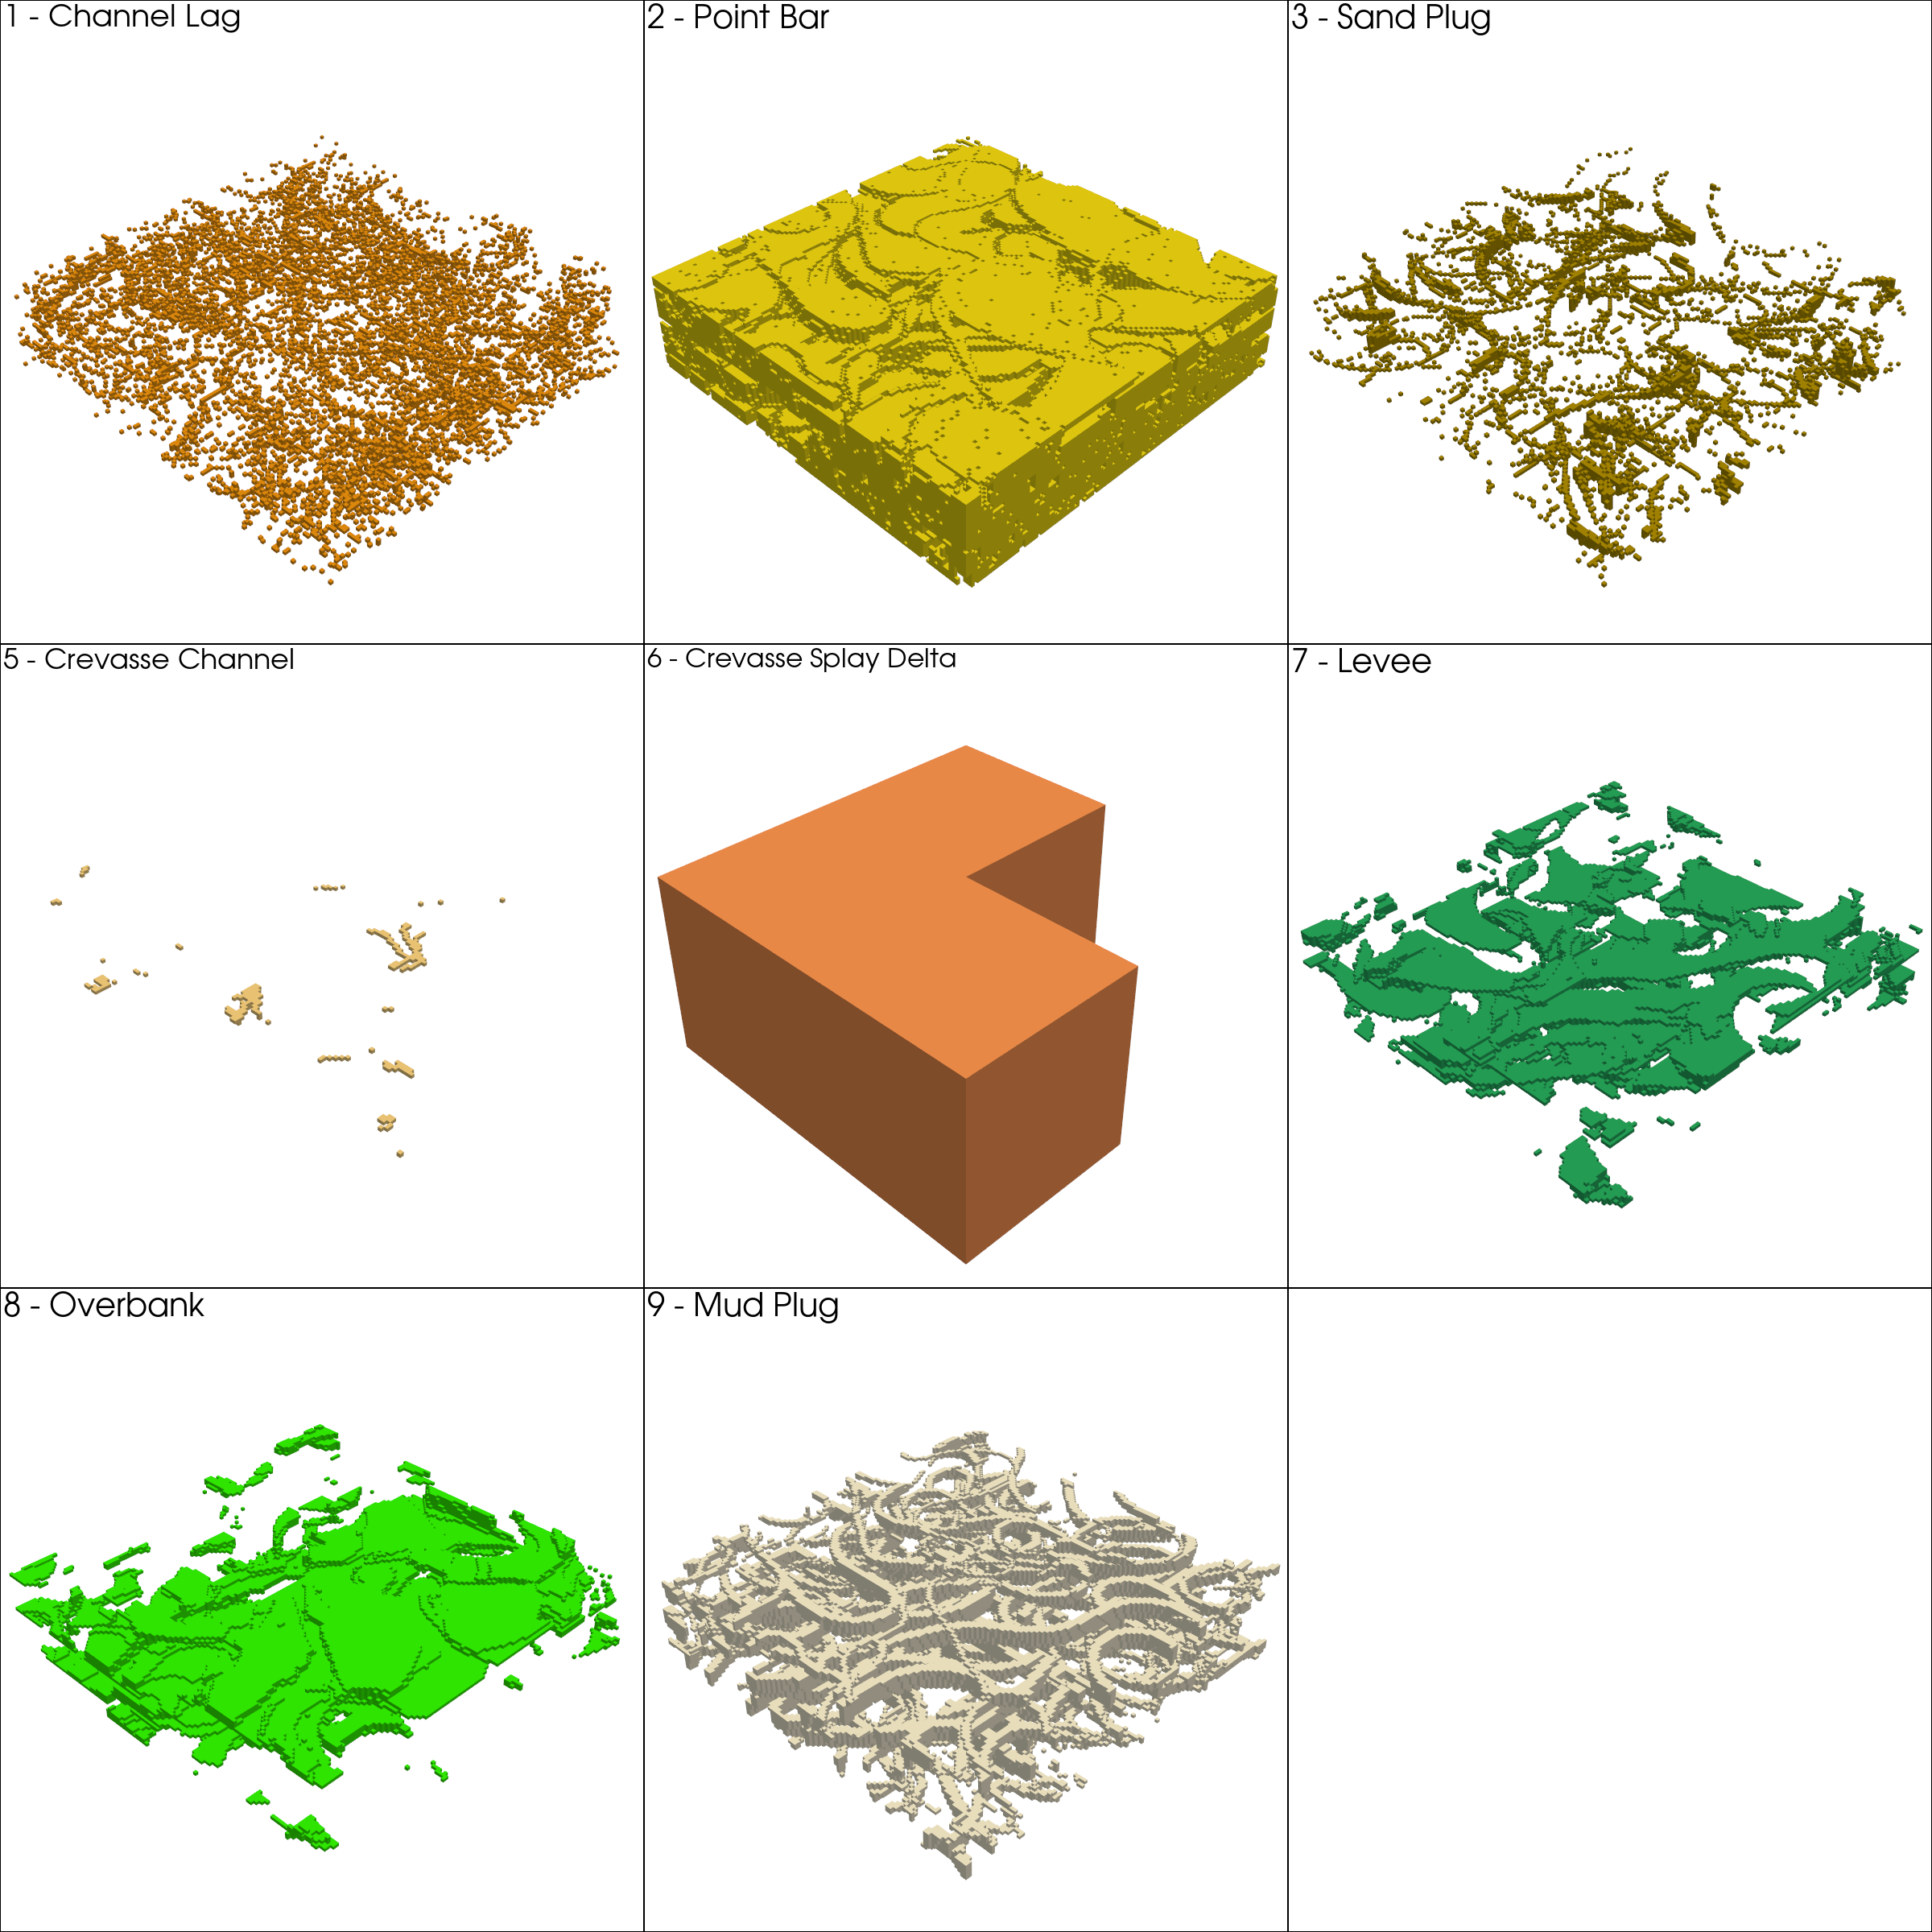

Saved 3D plot with 8 subplots to: 3D_plot_sample_11_all_facies.png


In [ ]:
import math

print("\n--- Phase 4: Generating 3D PyVista Plot for ALL Present Facies ---")

try:
    import pyvista as pv
except ImportError:
    print("Error: 'pyvista' is not installed. Please install it to run this cell.")
    pv = None

if pv:
    # 1. Select a random sample
    if not samples:
        raise FileNotFoundError("No .npy files found in the 'samples' list.")
        
    random_file = random.choice(samples)
    data_3d = np.load(random_file)
    nz, ny, nx = data_3d.shape

    # 2. Setup the PyVista Grid
    grid = pv.ImageData()
    grid.dimensions = (nx + 1, ny + 1, nz + 1)
    grid.cell_data['Facies'] = data_3d.transpose(2, 1, 0).flatten(order='F')

    # 3. Find unique facies dynamically
    # Use astype(int) to ensure they match our dictionary keys
    present_facies = np.unique(data_3d).astype(int)
    
    # Map integers to their descriptive titles using your loaded config
    facies_titles = {props['val']: name.replace('_', ' ').title() for name, props in facies_properties.items()}
    
    # 4. Calculate grid dimensions (Max 3 columns)
    num_plots = len(present_facies)
    num_cols = min(3, num_plots)
    num_rows = math.ceil(num_plots / 3)

    custom_cmap = custom_plots.FaciesColorMap()

    # Setup Plotter with dynamic rows/cols and auto-scaled window size
    window_width = 800 * num_cols
    window_height = 800 * num_rows
    plotter = pv.Plotter(shape=(num_rows, num_cols), off_screen=True, window_size=(window_width, window_height))

    for i, f_val in enumerate(present_facies):
        row = i // 3
        col = i % 3
        plotter.subplot(row, col)
        
        # Add title text for each subplot
        f_name = facies_titles.get(f_val, "Unknown Facies")
        plotter.add_text(f"{f_val} - {f_name}", font_size=16, color='black', shadow=False)
        
        # Threshold to only include the current facies
        threshed = grid.threshold([f_val - 0.5, f_val + 0.5], scalars='Facies')

        if threshed.n_points > 0:
            plotter.add_mesh(
                threshed, 
                scalars='Facies',
                cmap=custom_cmap, 
                clim=[0, 13], 
                show_edges=False, 
                show_scalar_bar=False,
                ambient=0.2,
                diffuse=0.8
            )

        plotter.view_isometric()

    # 5. Save and Display
    sample_name = os.path.splitext(os.path.basename(random_file))[0]
    plot_path = f"3D_plot_{sample_name}_all_facies.png"
    
    plotter.show(screenshot=plot_path, jupyter_backend='static')
    print(f"Saved 3D plot with {num_plots} subplots to: {plot_path}")

## Sample Diversity